<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/100k_Test/EarlyFusionCNN_Standardized_cleaner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Imports and Reproducibility

In [29]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/REU ECG Analysis
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/REU ECG Analysis
BCNN		    ECG_waveforms_1K.npy      outputs
ECG_metrics_1K.npy  EchoNext_EchoData_5K.csv  PaperFigures


Using compute engine: cpu
Loading datasets...
Filtering waveforms axis-by-axis using Butterworth filters...
Data partitioning: Train=720 | Val=180 | Test=100
Training structural classification network model...

================ INDIVIDUAL EVALUATION PER-TEST SAMPLE LOGS ================
Sample Sequential #000 (Original DF Index: 0521) | True Label: 1 | Prediction: 0 | Confidence: 0.8613 | Uncertainty (Std): 0.0000
Sample Sequential #001 (Original DF Index: 0737) | True Label: 0 | Prediction: 0 | Confidence: 0.7282 | Uncertainty (Std): 0.0000
Sample Sequential #002 (Original DF Index: 0740) | True Label: 0 | Prediction: 1 | Confidence: 0.7493 | Uncertainty (Std): 0.0000
Sample Sequential #003 (Original DF Index: 0660) | True Label: 0 | Prediction: 0 | Confidence: 0.7276 | Uncertainty (Std): 0.0000
Sample Sequential #004 (Original DF Index: 0411) | True Label: 0 | Prediction: 0 | Confidence: 0.5218 | Uncertainty (Std): 0.0000
Sample Sequential #005 (Original DF Index: 0678) | True Label:

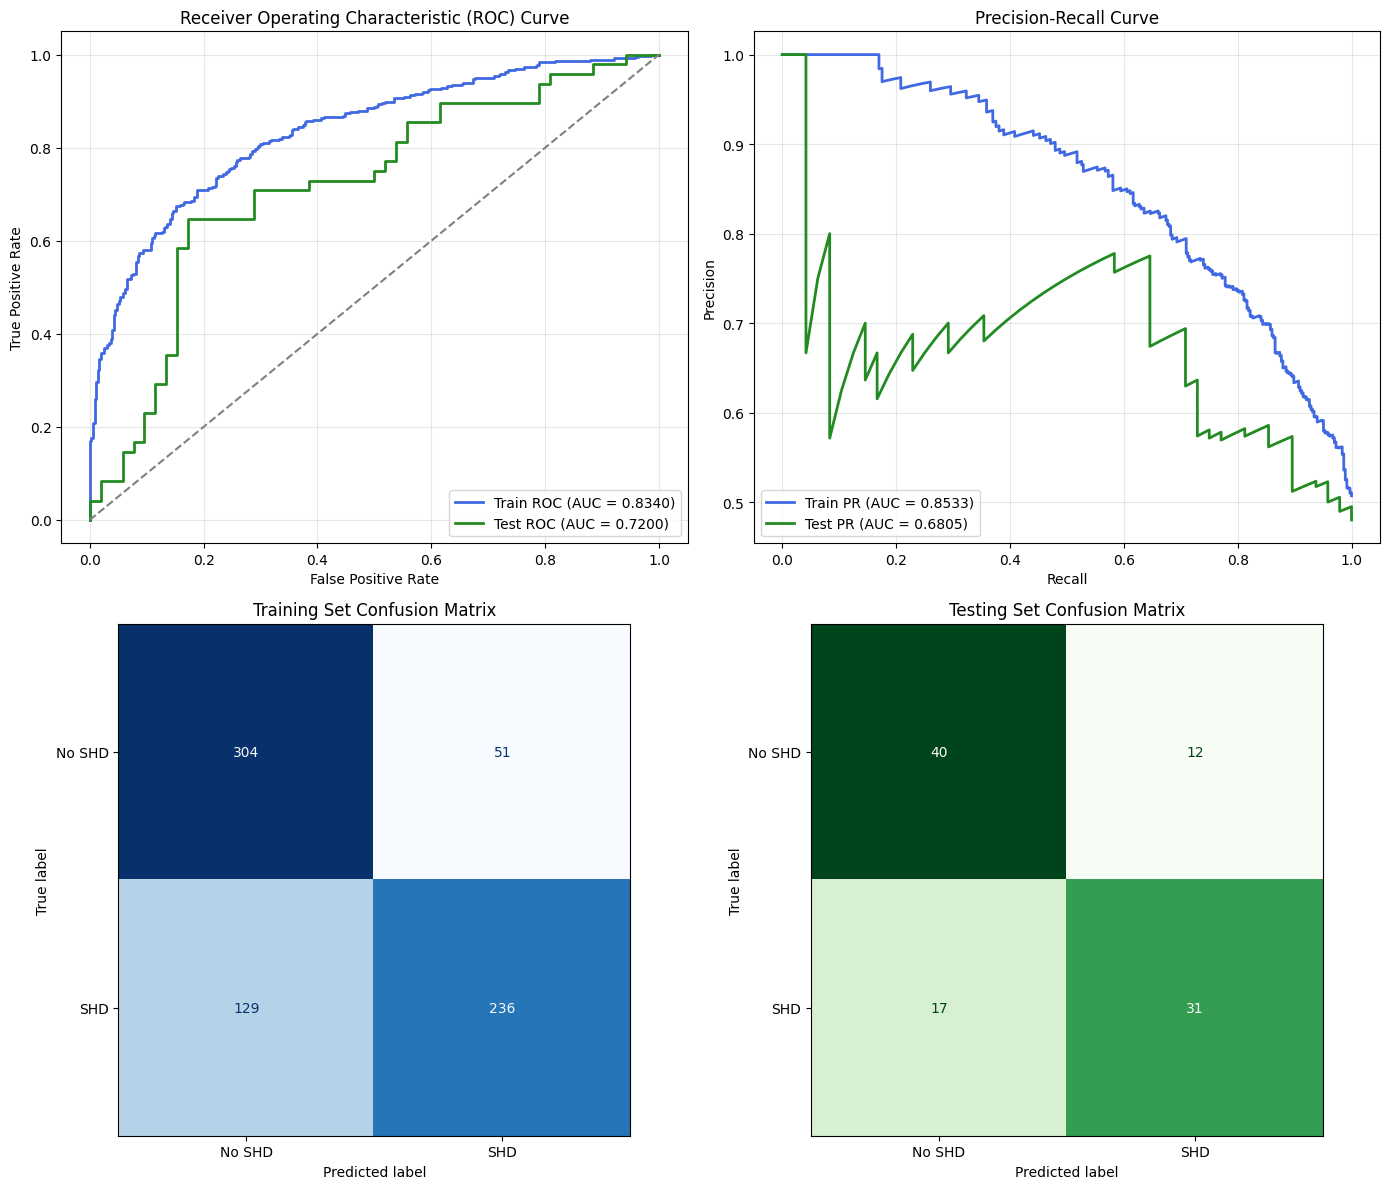

In [36]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay
)

# ──────────────────────────────────────────────────────────────────────
# 1. GLOBAL CONFIGURATION & REPRODUCIBILITY
# ──────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute engine: {device}")

CATEGORICAL_COLS = ["race_ethnicity", "sex"]
CONTINUOUS_COLS  = [
    "age_at_ecg",
    "ventricular_rate",
    "atrial_rate",
    "pr_interval",
    "qrs_duration",
    "qt_corrected"
]
ALL_DEMO_COLS = CATEGORICAL_COLS + CONTINUOUS_COLS

ECG_SAMPLING_RATE_HZ = 500
FILTER_LOW_HZ = 0.5
FILTER_HIGH_HZ = 40.0
FILTER_ORDER = 4

# ──────────────────────────────────────────────────────────────────────
# 2. SIGNAL PROCESSING & PREPROCESSING PIPELINES
# ──────────────────────────────────────────────────────────────────────
def bandpass_filter_ecg(signal_array, fs=ECG_SAMPLING_RATE_HZ,
                         low=FILTER_LOW_HZ, high=FILTER_HIGH_HZ, order=FILTER_ORDER):
    nyquist = 0.5 * fs
    b, a = butter(order, [low / nyquist, high / nyquist], btype="band")
    filtered = filtfilt(b, a, signal_array, axis=0)
    return filtered.astype(np.float32)

def preprocess_demographics_pipeline(
    df: pd.DataFrame,
    scaler: StandardScaler = None,
    imputer: KNNImputer = None,
    knn_k: int = 5,
    fit: bool = True,
    known_feature_names: list[str] = None # Re-added argument for consistent feature sets
) -> tuple[np.ndarray, StandardScaler, KNNImputer, list[str]]:
    df_working = df[ALL_DEMO_COLS].copy()

    cat_codes = df_working[CATEGORICAL_COLS].apply(
        lambda col: col.astype("category").cat.codes.replace(-1, np.nan)
    )
    cont_part = df_working[CONTINUOUS_COLS].astype(float)
    imputer_input = pd.concat([cat_codes, cont_part], axis=1)

    if imputer is None:
        imputer = KNNImputer(n_neighbors=knn_k)

    if fit:
        imputed = imputer.fit_transform(imputer_input)
    else:
        imputed = imputer.transform(imputer_input)

    imputed_df = pd.DataFrame(imputed, columns=ALL_DEMO_COLS, index=df_working.index)

    for col in CATEGORICAL_COLS:
        original_cats = df_working[col].astype("category").cat.categories
        codes_rounded = imputed_df[col].round().astype(int).clip(0, len(original_cats) - 1)
        imputed_df[col] = original_cats[codes_rounded].values

    ohe_df = pd.get_dummies(imputed_df, columns=CATEGORICAL_COLS, dtype=float)

    current_feature_names = [] # Initialize

    if fit:
        # If fitting, these are the new "known" feature names
        current_feature_names = list(ohe_df.columns)
    else:
        # If not fitting, ensure columns match the known_feature_names
        if known_feature_names is None:
            raise ValueError("known_feature_names must be provided when fit=False")
        # Reindex to ensure all known columns are present, filling missing with 0
        # Also ensures order of columns is consistent
        ohe_df = ohe_df.reindex(columns=known_feature_names, fill_value=0)
        current_feature_names = known_feature_names # Use the provided known names

    if scaler is None:
        scaler = StandardScaler()

    cont_indices = [current_feature_names.index(c) for c in CONTINUOUS_COLS]
    arr = ohe_df.values.astype(np.float32)

    if fit:
        arr[:, cont_indices] = scaler.fit_transform(arr[:, cont_indices])
    else:
        arr[:, cont_indices] = scaler.transform(arr[:, cont_indices])

    return arr, scaler, imputer, current_feature_names

# ──────────────────────────────────────────────────────────────────────
# 3. PYTORCH DATASET INFRASTRUCTURE
# ──────────────────────────────────────────────────────────────────────
class FusedDataset(Dataset):
    def __init__(self, X_ts: np.ndarray, X_demo: np.ndarray, y: np.ndarray):
        assert len(X_ts) == len(X_demo) == len(y), "Sample size dimension mismatch across features."
        self.X_ts   = torch.tensor(X_ts,   dtype=torch.float32)
        self.X_demo = torch.tensor(X_demo, dtype=torch.float32)
        self.y      = torch.tensor(y,      dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_ts[idx], self.X_demo[idx], self.y[idx]

# ──────────────────────────────────────────────────────────────────────
# 4. NEURAL NETWORK ARCHITECTURE DEFINITIONS
# ──────────────────────────────────────────────────────────────────────
class DemographicMLP(nn.Module):
    def __init__(self, input_dim=8, output_dim=16):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, output_dim),
            nn.BatchNorm1d(output_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.mlp(x)

class HeartDiseaseNet(nn.Module):
    def __init__(self, sequence_length=2500, num_classes=2, in_channels=12, demo_dim=20):
        super().__init__()

        self.ts_features = nn.Sequential(
            nn.Conv1d(in_channels, 16, kernel_size=7, padding=3),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.AdaptiveAvgPool1d(250),

            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.6),
            nn.AdaptiveAvgPool1d(25),

            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.8),
            nn.AdaptiveAvgPool1d(1),
        )

        self.demog_features = DemographicMLP(input_dim=demo_dim, output_dim=16)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 + 16, num_classes)
        )

    def forward(self, ts_input, demog_input):
        ts_emb = self.ts_features(ts_input)
        ts_emb = torch.flatten(ts_emb, start_dim=1)

        demog_emb = self.demog_features(demog_input)
        fused_features = torch.cat((ts_emb, demog_emb), dim=1)

        logits = self.classifier(fused_features)
        return logits

# ──────────────────────────────────────────────────────────────────────
# 5. METRICS COMPUTATION AND CALIBRATION ERRORS
# ──────────────────────────────────────────────────────────────────────
def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    n_total = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        if i == n_bins - 1:
            in_bin = (y_prob >= lo) & (y_prob <= hi)
        else:
            in_bin = (y_prob >= lo) & (y_prob < hi)

        n_bin = in_bin.sum()
        if n_bin == 0:
            continue

        acc_bin        = y_true[in_bin].mean()
        confidence_bin = y_prob[in_bin].mean()
        ece           += (n_bin / n_total) * abs(acc_bin - confidence_bin)

    return ece

def calculate_comprehensive_metrics(model, data_loader, device, threshold=0.5):
    model.eval()
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in data_loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)
            logits = model(X_ts_b, X_demo_b)
            probs  = F.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())
            all_labels.append(y_b.numpy())

    y_prob = np.concatenate(all_probs)
    y_true = np.concatenate(all_labels)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    metrics = {
        "accuracy":                   accuracy_score(y_true, y_pred),
        "balanced_accuracy":          balanced_accuracy_score(y_true, y_pred),
        "auroc":                      roc_auc_score(y_true, y_prob),
        "auprc":                      average_precision_score(y_true, y_prob),
        "sensitivity":                tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "specificity":                tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "brier_score":                brier_score_loss(y_true, y_prob),
        "expected_calibration_error": expected_calibration_error(y_true, y_prob, n_bins=10),
        "confusion_matrix":           confusion_matrix(y_true, y_pred, labels=[0, 1]),
        "y_true":                     y_true,
        "y_prob":                     y_prob
    }
    return metrics

def print_metrics_profile(title, metrics):
    print(f"\n==================== {title.upper()} PERFORMANCE ====================")
    print(f"Accuracy Score:                 {metrics['accuracy']:.6f}")
    print(f"Balanced Accuracy:             {metrics['balanced_accuracy']:.6f}")
    print(f"AUROC Metric:                   {metrics['auroc']:.6f}")
    print(f"AUPRC Metric:                   {metrics['auprc']:.6f}")
    print(f"Sensitivity (Recall):           {metrics['sensitivity']:.6f}")
    print(f"Specificity:                    {metrics['specificity']:.6f}")
    print(f"Brier Uncertainty Score:        {metrics['brier_score']:.6f}")
    print(f"Expected Calibration Error:     {metrics['expected_calibration_error']:.6f}")
    print(f"Confusion Matrix Configuration:\n{metrics['confusion_matrix']}")

# ──────────────────────────────────────────────────────────────────────
# 6. EXECUTION RUNTIME PIPELINE
# ──────────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    # ── STEP A: DATA INGESTION ──
    print("Loading datasets...")
    ECG_raw = np.load('ECG_waveforms_1K.npy')[:1000]
    echo_df = pd.read_csv('EchoNext_EchoData_5K.csv').iloc[:1000].reset_index(drop=True)
    y_raw   = echo_df['shd_moderate_or_greater_flag'].to_numpy()

    # ── STEP B: WAVEFORM PRE-FILTERING ──
    print("Filtering waveforms axis-by-axis using Butterworth filters...")
    X_filtered = np.array([bandpass_filter_ecg(x) for x in ECG_raw])
    X_ts       = np.swapaxes(X_filtered, 1, 2)
    demo_df    = echo_df[ALL_DEMO_COLS].copy()

    # ── STEP C: DATASET PARTITIONING (90% / 10%) ──
    N = len(y_raw)
    indices = np.arange(N)
    np.random.seed(RANDOM_SEED)
    np.random.shuffle(indices)

    test_split_idx    = int(0.10 * N)
    test_indices      = indices[:test_split_idx]
    train_val_indices = indices[test_split_idx:]

    val_split_idx = int(0.20 * len(train_val_indices))
    val_indices   = train_val_indices[:val_split_idx]
    train_indices = train_val_indices[val_split_idx:]

    print(f"Data partitioning: Train={len(train_indices)} | Val={len(val_indices)} | Test={len(test_indices)}")

    # ── STEP D: DEMOGRAPHIC PREPROCESSING ON TRAIN/VAL PARALLELS ──
    train_val_df_raw = demo_df.iloc[train_val_indices]
    _, fitted_scaler, fitted_imputer, fitted_feature_names = preprocess_demographics_pipeline( # Renamed feature_names to fitted_feature_names
        train_val_df_raw, scaler=None, imputer=None, fit=True
    )

    demo_train, _, _, _ = preprocess_demographics_pipeline(demo_df.iloc[train_indices], scaler=fitted_scaler, imputer=fitted_imputer, fit=False, known_feature_names=fitted_feature_names)
    demo_val, _, _, _   = preprocess_demographics_pipeline(demo_df.iloc[val_indices],   scaler=fitted_scaler, imputer=fitted_imputer, fit=False, known_feature_names=fitted_feature_names)
    demo_test, _, _, _  = preprocess_demographics_pipeline(demo_df.iloc[test_indices],  scaler=fitted_scaler, imputer=fitted_imputer, fit=False, known_feature_names=fitted_feature_names)

    # ── STEP E: INITIALIZE PYTORCH DATA CONTEXTS ──
    train_dataset = FusedDataset(X_ts[train_indices], demo_train, y_raw[train_indices])
    val_dataset   = FusedDataset(X_ts[val_indices],   demo_val,   y_raw[val_indices])
    test_dataset  = FusedDataset(X_ts[test_indices],  demo_test,  y_raw[test_indices])

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

    # ── STEP F: INITIALIZE THE NETWORK ──
    model = HeartDiseaseNet(
        sequence_length = X_ts.shape[2],
        in_channels     = X_ts.shape[1],
        demo_dim        = demo_train.shape[1],
        num_classes     = 2
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=1, eta_min=1e-5)

    # ── STEP G: NETWORK OPTIMIZATION LOOPS ──
    print("Training structural classification network model...")
    EPOCHS = 60

    for epoch in range(EPOCHS):
        model.train()
        for X_ts_b, X_demo_b, y_b in train_loader:
            X_ts_b, X_demo_b, y_b = X_ts_b.to(device), X_demo_b.to(device), y_b.to(device)

            optimizer.zero_grad()
            logits = model(X_ts_b, X_demo_b)
            loss   = criterion(logits, y_b)
            loss.backward()
            optimizer.step()
        scheduler.step()

    # ── STEP H: SAMPLE-BY-SAMPLE INDIVIDUAL PREDICTIVE EVALUATIONS ──
    print("\n================ INDIVIDUAL EVALUATION PER-TEST SAMPLE LOGS ================")
    model.eval()
    sample_counter = 0

    with torch.no_grad():
        for X_ts_b, X_demo_b, y_b in test_loader:
            X_ts_b, X_demo_b = X_ts_b.to(device), X_demo_b.to(device)

            logits = model(X_ts_b, X_demo_b)
            probs_matrix = F.softmax(logits, dim=1).cpu().numpy()

            for idx in range(X_ts_b.size(0)):
                true_val = y_b[idx].item()
                pred_val = np.argmax(probs_matrix[idx])
                confidence = probs_matrix[idx][pred_val]

                df_original_idx = test_indices[sample_counter]

                print(f"Sample Sequential #{sample_counter:03d} (Original DF Index: {df_original_idx:04d}) | "
                      f"True Label: {true_val} | Prediction: {pred_val} | "
                      f"Confidence: {confidence:.4f} | Uncertainty (Std): 0.0000")
                sample_counter += 1

    # ── STEP I: PERFORMANCE SUMMARY METRICS ──
    train_metrics = calculate_comprehensive_metrics(model, train_loader, device)
    test_metrics  = calculate_comprehensive_metrics(model, test_loader, device)

    print_metrics_profile("Training Set", train_metrics)
    print_metrics_profile("Testing Holdout Set", test_metrics)

    # ── STEP J: PLOT METRICS & VISUALIZATION PROFILES ──
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # 1. Receiver Operating Characteristic (ROC) Curves
    train_fpr, train_tpr, _ = roc_curve(train_metrics['y_true'], train_metrics['y_prob'])
    test_fpr, test_tpr, _ = roc_curve(test_metrics['y_true'], test_metrics['y_prob'])

    axes[0, 0].plot(train_fpr, train_tpr, color='royalblue', lw=2, label=f"Train ROC (AUC = {train_metrics['auroc']:.4f})")
    axes[0, 0].plot(test_fpr, test_tpr, color='forestgreen', lw=2, label=f"Test ROC (AUC = {test_metrics['auroc']:.4f})")
    axes[0, 0].plot([0, 1], [0, 1], color='grey', linestyle='--')
    axes[0, 0].set_xlabel('False Positive Rate')
    axes[0, 0].set_ylabel('True Positive Rate')
    axes[0, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
    axes[0, 0].legend(loc="lower right")
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Precision-Recall (PR) Curves
    train_precision, train_recall, _ = precision_recall_curve(train_metrics['y_true'], train_metrics['y_prob'])
    test_precision, test_recall, _ = precision_recall_curve(test_metrics['y_true'], test_metrics['y_prob'])

    axes[0, 1].plot(train_recall, train_precision, color='royalblue', lw=2, label=f"Train PR (AUC = {train_metrics['auprc']:.4f})")
    axes[0, 1].plot(test_recall, test_precision, color='forestgreen', lw=2, label=f"Test PR (AUC = {test_metrics['auprc']:.4f})")
    axes[0, 1].set_xlabel('Recall')
    axes[0, 1].set_ylabel('Precision')
    axes[0, 1].set_title('Precision-Recall Curve')
    axes[0, 1].legend(loc="lower left")
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Training Set Confusion Matrix
    ConfusionMatrixDisplay(
        confusion_matrix=train_metrics['confusion_matrix'],
        display_labels=["No SHD", "SHD"]
    ).plot(ax=axes[1, 0], cmap=plt.cm.Blues, colorbar=False)
    axes[1, 0].set_title("Training Set Confusion Matrix")

    # 4. Testing Set Confusion Matrix
    ConfusionMatrixDisplay(
        confusion_matrix=test_metrics['confusion_matrix'],
        display_labels=["No SHD", "SHD"]
    ).plot(ax=axes[1, 1], cmap=plt.cm.Greens, colorbar=False)
    axes[1, 1].set_title("Testing Set Confusion Matrix")

    plt.tight_layout()
    plt.show()